[[0. 0. 0. 0.]
 [0. 0. 1. 1.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
[['R0', 'S1', 'S3'], ['R0', 'S3']]
2
['R0+S1s -> R0+S1', 'R0+S3s -> R0+S3', 'S1+S2s -> S1+S2', 'S1+S3s -> S1+S3', 'S0s -> S0', 'S1s -> S1', 'S2s -> S2', 'S3s -> S3']
[[1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 1.]]
['R0+S1s -> R0+S1', 'R0+S3s -> R0+S3', 'S1+S2s -> S1+S2', 'S1+S3s -> S1+S3', 'S0s -> S0', 'S1s -> S1', 'S2s -> S2', 'S3s -> S3']
Complexes per class: [2, 2, 2, 2, 2, 2, 2, 2]
Reactions per class: [1, 1, 1, 1, 1, 1, 1, 1]
Extra conservations 0
Linkage group 1: {'R0+S1': 'R0+S1', 'R0+S1s': 'R0+S1s'}
Linkage group 2: {'R0+S3': 'R0+S3', 'R0+S3s': 'R0+S3s'}
Linkage group 3: {'S0s': 'S0s', 'S0': 'S0'}
Linkage group 4: {'S1': 'S1', 'S1s': 'S1s'}
Linkage group 5: {'S1+S2s': 'S1+S2s', 'S1+S2': 'S1+S2'}
Linkage group 6: {'S1+S3': 'S1+S3', 'S1+S3s': 'S1+S3s'}
Linkage group 7: {'S2': 'S2', 'S2s': 'S2s'}
Linkage group 8: {'S3s'

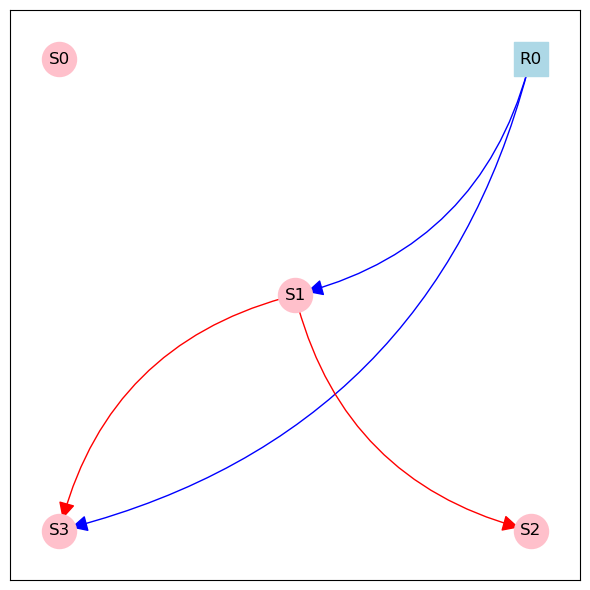

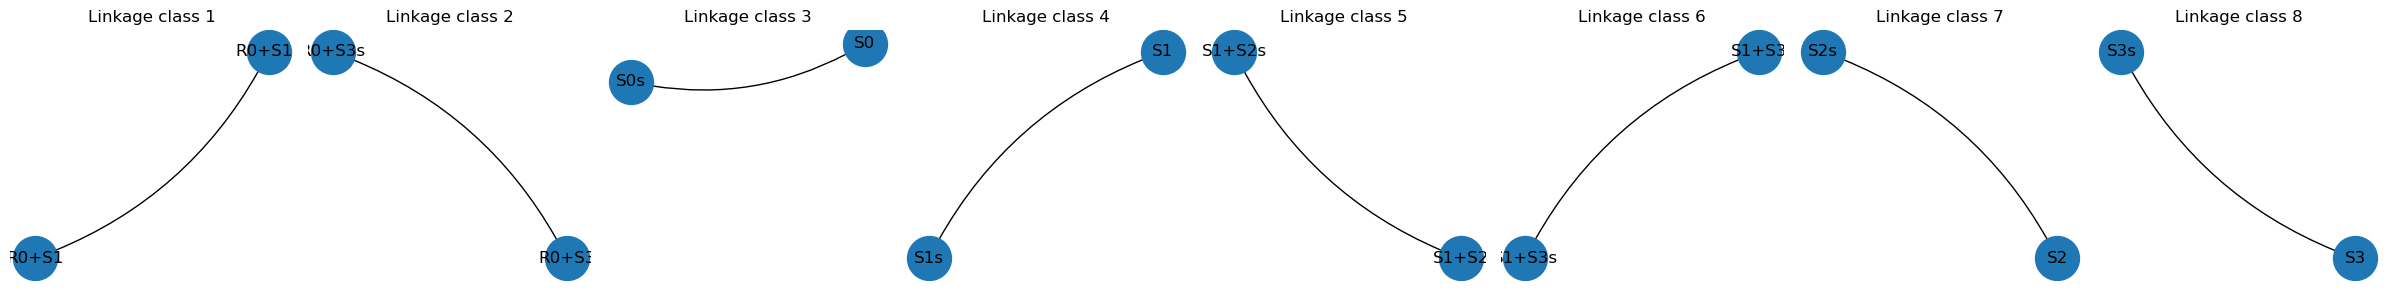

Remaining species after reduction: ['S0s', 'S1s', 'S2s', 'S3s']
Conservation constants (symbols): [const0, const1, const2, const3, const4]
Eliminated species solutions: {'R0': const0, 'S0': -S0s + const1, 'S1': -S1s + const2, 'S2': -S2s + const3, 'S3': -S3s + const4}


In [8]:
from CRNs import *
import numpy as np
import matplotlib.pyplot as plt
import sympy
import networkx as nx
import random
from sympy import Poly, Symbol


# --- Example usage with new class structure ---
# seed = 52
# np.random.seed(seed)
# random.seed(seed)

NR = 1
NS = 3
p_f = 0.75
p_r = 0
#species_names, reaction_strings, L, input_indices = generate_random_signaling_network(NR, NL, NL_in, prob, include_reverse=True, include_uncatalyzed=True)

#species_names, reaction_strings, L, adjacency_matrix, input_substrates_list = generate_dag_signaling_network(NR, NS, p_f, p_r, include_reverse=False, include_uncatalyzed=True)

# NS_vec = [1,1]

# NS_vec = [int(digit) for digit in ""]
# NS_vec.append(1)

# NS = sum(NS_vec)
# species_names, reaction_strings, L, adjacency_matrix, input_substrates_list = generate_layered_feedforward_signaling_network(NR, NS_vec, p_r, include_reverse=False, include_uncatalyzed=True)


NS = 4
save_path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/repositories/GlycanAnalysis/Python/SavedNetworks/"
sub_path = "NS" + str(NS) + ".pkl"  # Replace with your desired path
#save_networks_to_pickle(networks, save_path + sub_path)
filepath = save_path + sub_path
with open(filepath, 'rb') as f:
    networks = pickle.load(f)

n_paths = 2
sample_idx = 4
adjacency_matrix = networks[n_paths][sample_idx]['adjacency_matrix_0']
input_substrates_list = networks[n_paths][sample_idx]['input_substrates_list']

print(adjacency_matrix)

species_names, reaction_strings, L = generate_specified_dag_signaling_network(adjacency_matrix, input_substrates_list, include_reverse=False, include_uncatalyzed=True)


#species_names, reaction_strings, L = expand_catalyzed_reactions(species_names, reaction_strings, L)

#visualize_dag_signaling_network(adjacency_matrix, input_substrates, NR, NS)
G = get_digraph_from_adjacency_matrix(adjacency_matrix, input_substrates_list, NR, NS)
n_paths = count_simple_paths(G, f'R0', f'S{NS-1}')
print(n_paths)
print(len(n_paths))
#print(input_indices)
print(reaction_strings)
visualize_dag_signaling_network(adjacency_matrix, input_substrates_list, NR, NS)

# n_nodes = 3
# NS = 1
# prob = 1
# extra_reactions = ['A+B -> C+C']
# input_reactions_list = [['R0+A -> R0+B']]
# species_names, reaction_strings, L = generate_random_first_order_network(n_nodes, input_reactions_list, prob, extra_reactions = extra_reactions, include_reverse=False)
# #visualize_dag_signaling_network(adjacency_matrix, input_substrates, NR, NS)

print(L)
print(reaction_strings)

# NR = 1
# NL_vec = [2,2]
# species_names, reaction_strings, L = generate_feedforward_signaling_network(NR, NL_vec)



r_n = ReactionNetwork.from_reaction_strings(
    reaction_strings=reaction_strings,
    L=L,
    seed=42,
    species_names=species_names,
    force_reverse=True
)

# 1. Create the simulator
sim = ReactionNetworkSimulator(r_n)

print("Complexes per class:", r_n.complexes_per_class)
print("Reactions per class:", r_n.reactions_per_class)
print("Extra conservations", r_n.n_species - np.linalg.matrix_rank(r_n.Y @ r_n.A) - r_n.n_cons)

for i, node_assignment in enumerate(r_n.assignments):
    print(f"Linkage group {i+1}: {node_assignment}")

# symbolic ODEs
symbolic_rhs, species, rates = sim.get_symbolic_rhs()
reduced_rhs, remaining_syms, const_syms, rate_syms = sim.get_symbolic_reduced_rhs()


print(r_n.get_reaction_strings())

cycles = compute_cycles(r_n)


# Visualize linkage classes
sz = 3
fig, axes = plt.subplots(1, len(r_n.linkage_groups), figsize=(sz*len(r_n.linkage_groups), sz))

if len(r_n.linkage_groups) == 1:
    pos = nx.spring_layout(r_n.linkage_groups[0])
    nx.draw(r_n.linkage_groups[0], pos=pos, with_labels=True, ax=axes, node_size=1000, connectionstyle='arc3,rad=0.2', arrows=True)
    axes.set_title("Linkage class 1")
else:
    for i, (G, ax) in enumerate(zip(r_n.linkage_groups, axes)):
        pos = nx.spring_layout(G)
        nx.draw(G, pos=pos, with_labels=True, ax=ax, node_size=1000, connectionstyle='arc3,rad=0.2', arrows=True)
        ax.set_title(f"Linkage class {i+1}")
plt.tight_layout()
plt.show()

# 2. Reduce the ODE system using conservation laws
sim.solve_conservation_laws()
print("Remaining species after reduction:", sim.remaining_species)
print("Conservation constants (symbols):", sim.const_syms)
print("Eliminated species solutions:", sim.elimination_solutions)

In [19]:
from CRNs import *
import numpy as np
import matplotlib.pyplot as plt
import sympy
import networkx as nx
import random
from sympy import Poly, Symbol

NR = 1
NS = 3
p_f = 0.75
p_r = 0
NS_vec = [2,1]
species_names, reaction_strings, L, adjacency_matrix, input_substrates_list = generate_layered_feedforward_signaling_network(NR, NS_vec, p_r, include_reverse=False, include_uncatalyzed=True)

print(L)
print(reaction_strings)

[[1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 1.]]
['R0+S0s -> R0+S0', 'R0+S1s -> R0+S1', 'S0+S2s -> S0+S2', 'S1+S2s -> S1+S2', 'S0s -> S0', 'S1s -> S1', 'S2s -> S2']


In [2]:
def expand_catalyzed_reactions(species_names, reaction_strings, L):
    """
    Expand catalyzed reactions into elementary steps with intermediate complexes.
    
    Args:
        species_names: List of species names
        reaction_strings: List of reaction strings
        L: Linkage matrix (numpy array)
        
    Returns:
        tuple: (new_species_names, new_reaction_strings, new_L)
            - new_species_names: Updated list of species names including intermediates
            - new_reaction_strings: Updated list of reaction strings with expanded reactions
            - new_L: Updated linkage matrix
    """
    def has_catalyst(reaction_string):
        """
        Check if any species appears on both sides of the reaction.
        
        Args:
            reaction_string: Reaction string like 'S0+S1s -> S0+S1'
            
        Returns:
            bool: True if any species appears on both sides
        """
        # Split into reactants and products
        parts = reaction_string.split('->')
        if len(parts) != 2:
            return False
        
        reactants_str = parts[0].strip()
        products_str = parts[1].strip()
        
        # Parse species from each side
        reactants = set(s.strip() for s in reactants_str.split('+'))
        products = set(s.strip() for s in products_str.split('+'))
        
        # Check if any species appears in both
        return len(reactants & products) > 0


    def split_catalyzed_reaction(reaction_string):
        """
        Split a catalyzed reaction into two elementary steps with an intermediate complex.
        Assumes a catalyst species appears on both sides.
        
        Args:
            reaction_string: Reaction string like 'S0+S1s -> S0+S1'
            
        Returns:
            tuple: (intermediate_name, reaction1, reaction2)
                - intermediate_name: Name of the intermediate complex (e.g., 'S0_S1s')
                - reaction1: Complex formation reaction (e.g., 'S0+S1s -> S0_S1s')
                - reaction2: Complex dissociation reaction (e.g., 'S0_S1s -> S0+S1')
        """
        # Split into reactants and products
        parts = reaction_string.split('->')
        reactants_str = parts[0].strip()
        products_str = parts[1].strip()
        
        # Parse species from each side
        reactants = [s.strip() for s in reactants_str.split('+')]
        products = [s.strip() for s in products_str.split('+')]
        
        # Create intermediate name by joining all reactants with underscores
        intermediate_name = '_'.join(reactants)
        
        # Create reaction 1: reactants -> intermediate (complex formation)
        reaction1 = f"{'+'.join(reactants)} -> {intermediate_name}"
        
        # Create reaction 2: intermediate -> products (complex dissociation)
        reaction2 = f"{intermediate_name} -> {'+'.join(products)}"
        
        return intermediate_name, reaction1, reaction2, list(set(reactants) | set(products))

    new_species_names = species_names.copy()
    new_reaction_strings = reaction_strings.copy()
    new_L = L.copy()
    for reaction_string in reaction_strings:
        if has_catalyst(reaction_string):
            intermediate_name, reaction1, reaction2, involved_species = split_catalyzed_reaction(reaction_string)
            involved_indices = [species_names.index(species) for species in involved_species]
            new_species_names.append(intermediate_name)
            new_reaction_strings.remove(reaction_string)
            new_reaction_strings.append(reaction1)
            new_reaction_strings.append(reaction2)
            new_l = np.zeros(len(new_L))
            for i in range(len(new_L)):
                if L[i, involved_indices].sum() > 0:
                    new_l[i] = 1
            new_L = np.column_stack([new_L, new_l])
    
    return new_species_names, new_reaction_strings, new_L

new_species_names, new_reaction_strings, new_L = expand_catalyzed_reactions(species_names, reaction_strings, L)
print(species_names)
print(reaction_strings)
print(L)
print(new_species_names)
print(new_reaction_strings)
print(new_L)

r_n = ReactionNetwork.from_reaction_strings(
    reaction_strings=new_reaction_strings,
    L=new_L,
    seed=42,
    species_names=new_species_names,
    force_reverse=True
)


['R0', 'S0s', 'S0', 'S1s', 'S1', 'S2s', 'S2', 'S3s', 'S3']
['R0+S0s -> R0+S0', 'R0+S1s -> R0+S1', 'S0+S3s -> S0+S3', 'S0s -> S0', 'S1s -> S1', 'S2s -> S2', 'S3s -> S3']
[[1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 1.]]
['R0', 'S0s', 'S0', 'S1s', 'S1', 'S2s', 'S2', 'S3s', 'S3', 'R0_S0s', 'R0_S1s', 'S0_S3s']
['S0s -> S0', 'S1s -> S1', 'S2s -> S2', 'S3s -> S3', 'R0+S0s -> R0_S0s', 'R0_S0s -> R0+S0', 'R0+S1s -> R0_S1s', 'R0_S1s -> R0+S1', 'S0+S3s -> S0_S3s', 'S0_S3s -> S0+S3']
[[1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0.]
 [0. 1. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1.]
 [0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 1.]]


# Create networks to save

[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 0.]]
{'input_substrates_list': [[1]], 'adjacency_matrix_0': array([[0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 0.]]), 'adjacency_matrix_1': array([[0., 0., 1.],
       [0., 0., 1.],
       [1., 1., 0.]])}
n_paths: 1
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 0.]]
[[0. 0. 1.]
 [0. 0. 1.]
 [1. 1. 0.]]


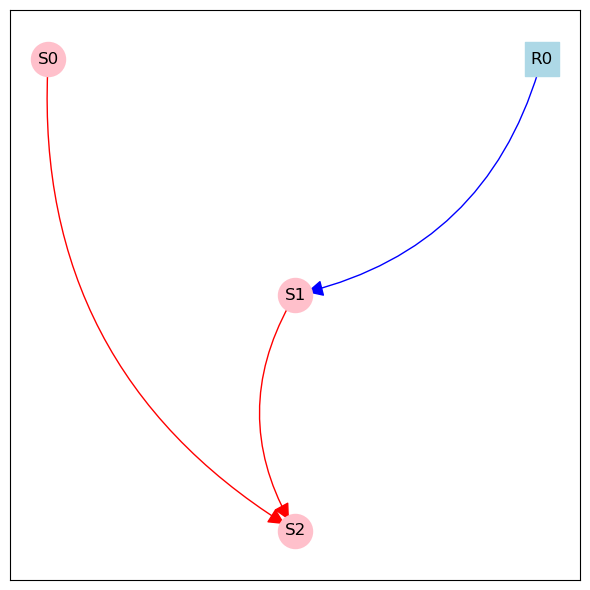

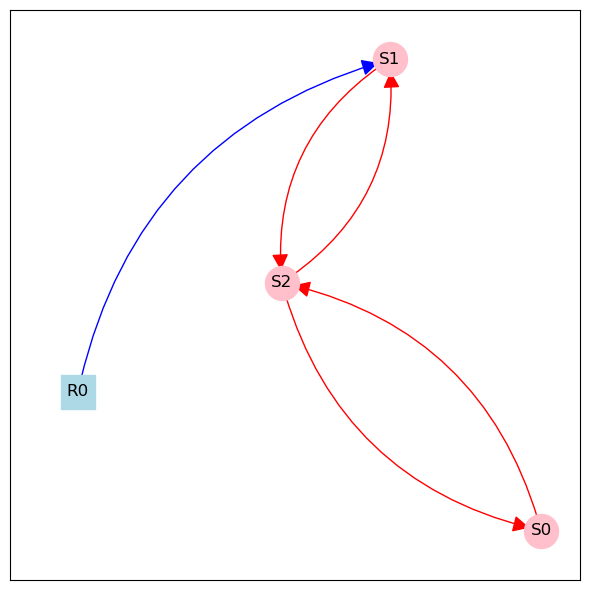

In [2]:
from CRNs import *
import numpy as np
import matplotlib.pyplot as plt
import sympy
import networkx as nx
import random

seed = 52
np.random.seed(seed)
random.seed(seed)

NR = 1
NS = 3
p_f = 0.5
p_r = 0

# NS_vec = [1,1]
# NS_vec = [int(digit) for digit in ""]
# NS_vec.append(1)
# NS = sum(NS_vec)
#species_names, reaction_strings, L, adjacency_matrix, input_substrates_list = generate_layered_feedforward_signaling_network(NR, NS_vec, p_r, include_reverse=False, include_uncatalyzed=True)

species_names, reaction_strings_0, L, adjacency_matrix_0, input_substrates_list = generate_dag_signaling_network(NR, NS, p_f, 0, include_reverse=False, include_uncatalyzed=True)

print(adjacency_matrix_0)
# species_names, reaction_strings, L, adjacency_matrix_1, input_substrates_list = generate_dag_signaling_network(NR, NS, p_f, 1, include_reverse=False, include_uncatalyzed=True)

reaction_strings_1, adjacency_matrix_1 = \
                add_recurrent_connections(adjacency_matrix_0, reaction_strings_0, False, input_substrates_list, NR, NS, 1)

dict_to_save = {'input_substrates_list': input_substrates_list, 'adjacency_matrix_0': adjacency_matrix_0, 'adjacency_matrix_1': adjacency_matrix_1}
print(dict_to_save)
G = get_digraph_from_adjacency_matrix(adjacency_matrix_0, input_substrates_list, NR, NS)
n_paths = count_simple_paths(G, f'R0', f'S{NS-1}')
print("n_paths:", len(n_paths))
print(adjacency_matrix_0)
print(adjacency_matrix_1)
v1 = visualize_dag_signaling_network(adjacency_matrix_0, input_substrates_list, NR, NS)
v2 = visualize_dag_signaling_network(adjacency_matrix_1, input_substrates_list, NR, NS)




In [9]:
def sample_dag_networks_by_path_count(NR, NS, p_f, p_r=0, 
                                       max_n_paths=10, 
                                       n_samples_per_path_count=5,
                                       max_attempts=10000,
                                       include_reverse=False,
                                       include_uncatalyzed=True):
    """
    Sample DAG signaling networks and organize them by path count.
    Ensures no duplicate networks (based on adjacency_matrix_0 equality) are stored.
    
    Parameters:
    -----------
    NR : int
        Number of receptors
    NS : int
        Number of species
    p_f : float
        Forward probability
    p_r : float
        Reverse probability (default: 0)
    max_n_paths : int
        Maximum number of paths to collect samples for
    n_samples_per_path_count : int
        Number of unique network samples to collect for each path count
    max_attempts : int
        Maximum number of sampling attempts before stopping
    include_reverse : bool
        Whether to include reverse reactions
    include_uncatalyzed : bool
        Whether to include uncatalyzed reactions
        
    Returns:
    --------
    dict : Outer dict with keys as n_paths counts, values as inner dicts
           Inner dicts have keys as sample indices and values as network data dicts
    """
    
    # Outer dict: {n_paths: {sample_idx: dict_to_save}}
    networks_by_path_count = {}
    
    # Initialize inner dicts for each possible path count (0 to max_n_paths)
    for n_paths in range(max_n_paths + 1):
        networks_by_path_count[n_paths] = {}
    
    seed = 0
    attempts = 0
    duplicates_found = 0
    
    print(f"Sampling networks with NR={NR}, NS={NS}, p_f={p_f}...")
    print(f"Target: {n_samples_per_path_count} samples for each path count from 0 to {max_n_paths}")
    
    def is_duplicate(adjacency_matrix_new, networks_dict):
        """Check if adjacency_matrix_new already exists in networks_dict"""
        for sample_data in networks_dict.values():
            if np.array_equal(adjacency_matrix_new, sample_data['adjacency_matrix_0']):
                return True
        return False
    
    while attempts < max_attempts:
        # Check if we have enough samples for all path counts
        all_filled = all(
            len(networks_by_path_count[n]) >= n_samples_per_path_count 
            for n in range(max_n_paths + 1)
        )
        
        if all_filled:
            print(f"\nCompleted! Collected {n_samples_per_path_count} samples for each path count.")
            break
        
        # Set random seed
        np.random.seed(seed)
        random.seed(seed)
        
        try:
            # Generate two networks with different parameters
            species_names, reaction_strings_0, L, adjacency_matrix_0, input_substrates_list = \
                generate_dag_signaling_network(NR, NS, p_f, 0, 
                                               include_reverse=include_reverse, 
                                               include_uncatalyzed=include_uncatalyzed)
            
            # species_names, reaction_strings, L, adjacency_matrix_1, input_substrates_list = \
            #     generate_dag_signaling_network(NR, NS, p_f, 1, 
            #                                    include_reverse=include_reverse, 
            #                                    include_uncatalyzed=include_uncatalyzed)

            reaction_strings_1, adjacency_matrix_1 = \
                add_recurrent_connections(adjacency_matrix_0, reaction_strings_0, include_reverse, input_substrates_list, NR, NS, 1)
            
            # Count paths using adjacency_matrix_0
            G = get_digraph_from_adjacency_matrix(adjacency_matrix_0, input_substrates_list, NR, NS)
            paths = count_simple_paths(G, f'R0', f'S{NS-1}')
            n_paths = len(paths)
            
            # Store if we need more samples for this path count and it's within our range
            if n_paths <= max_n_paths:
                if len(networks_by_path_count[n_paths]) < n_samples_per_path_count:
                    # Check for duplicates
                    if not is_duplicate(adjacency_matrix_0, networks_by_path_count[n_paths]):
                        # Create dict to save
                        dict_to_save = {
                            'seed': seed,
                            'input_substrates_list': input_substrates_list,
                            'adjacency_matrix_0': adjacency_matrix_0,
                            'adjacency_matrix_1': adjacency_matrix_1
                        }
                        
                        sample_idx = len(networks_by_path_count[n_paths])
                        networks_by_path_count[n_paths][sample_idx] = dict_to_save
                        
                        if (attempts + 1) % 100 == 0:
                            # Progress update
                            filled_counts = sum(
                                1 for n in range(max_n_paths + 1) 
                                if len(networks_by_path_count[n]) >= n_samples_per_path_count
                            )
                            print(f"Attempt {attempts + 1}: Found network with {n_paths} paths (seed={seed}). "
                                  f"Progress: {filled_counts}/{max_n_paths + 1} path counts complete. "
                                  f"Duplicates skipped: {duplicates_found}")
                    else:
                        duplicates_found += 1
        
        except Exception as e:
            # Skip networks that cause errors
            if attempts % 1000 == 0:
                print(f"Warning at attempt {attempts}: {e}")
            pass
        
        seed += 1
        attempts += 1
    
    if attempts >= max_attempts:
        print(f"\nReached maximum attempts ({max_attempts})")
        print(f"Total duplicates found and skipped: {duplicates_found}")
        print("Sample counts by path count:")
        for n_paths in range(max_n_paths + 1):
            count = len(networks_by_path_count[n_paths])
            status = "✓" if count >= n_samples_per_path_count else "✗"
            print(f"  {status} n_paths={n_paths}: {count}/{n_samples_per_path_count} samples")
    else:
        print(f"Total duplicates found and skipped: {duplicates_found}")
    
    return networks_by_path_count


# Example usage:

NR = 1
NS = 2
p_f = 0.5

# Sample networks
networks = sample_dag_networks_by_path_count(
    NR=NR, 
    NS=NS, 
    p_f=p_f,
    max_n_paths=9,
    n_samples_per_path_count=1000,
    max_attempts=1000000
)

# Example: Access a specific network
# networks[n_paths][sample_idx] gives you the dict_to_save for that network

# Print summary
print("\n=== Summary ===")
for n_paths, samples in networks.items():
    if len(samples) > 0:
        print(f"n_paths={n_paths}: {len(samples)} samples collected")
        # Example: show first sample's seed
        if 0 in samples:
            print(f"  First sample seed: {samples[0]['seed']}")

print(networks)

Sampling networks with NR=1, NS=2, p_f=0.5...
Target: 1000 samples for each path count from 0 to 9

Reached maximum attempts (1000000)
Total duplicates found and skipped: 999996
Sample counts by path count:
  ✗ n_paths=0: 1/1000 samples
  ✗ n_paths=1: 2/1000 samples
  ✗ n_paths=2: 1/1000 samples
  ✗ n_paths=3: 0/1000 samples
  ✗ n_paths=4: 0/1000 samples
  ✗ n_paths=5: 0/1000 samples
  ✗ n_paths=6: 0/1000 samples
  ✗ n_paths=7: 0/1000 samples
  ✗ n_paths=8: 0/1000 samples
  ✗ n_paths=9: 0/1000 samples

=== Summary ===
n_paths=0: 1 samples collected
  First sample seed: 0
n_paths=1: 2 samples collected
  First sample seed: 1
n_paths=2: 1 samples collected
  First sample seed: 11
{0: {0: {'seed': 0, 'input_substrates_list': [[0]], 'adjacency_matrix_0': array([[0., 0.],
       [0., 0.]]), 'adjacency_matrix_1': array([[0., 0.],
       [1., 0.]])}}, 1: {0: {'seed': 1, 'input_substrates_list': [[1]], 'adjacency_matrix_0': array([[0., 1.],
       [0., 0.]]), 'adjacency_matrix_1': array([[0., 

In [10]:
save_path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/repositories/GlycanAnalysis/Python/SavedNetworks/"
sub_path = "NS2.pkl"  # Replace with your desired path
#save_networks_to_pickle(networks, save_path + sub_path)
filepath = save_path + sub_path
with open(filepath, 'wb') as f:
    pickle.dump(networks, f)
    

Number of paths from R0 to S4: 3
Number of paths from R0 to S3: 2
Number of paths from R1 to S4: 3
Number of paths from R1 to S3: 1


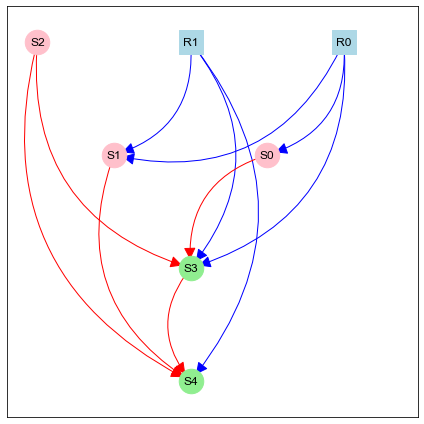

In [5]:
from CRNs import *
import numpy as np
import matplotlib.pyplot as plt
import sympy
import networkx as nx
import random
from sympy import Poly, Symbol

seed = 3
random.seed(seed)
np.random.seed(seed)

NR = 2 
NS = 5
p_f = 0.5
include_reverse = False
include_uncatalyzed = True
species_names, reaction_strings, L, adjacency_matrix, input_substrates_list = generate_dag_signaling_network(NR, NS, p_f, 0, 
                                               include_reverse=include_reverse, 
                                               include_uncatalyzed=include_uncatalyzed)

G = get_digraph_from_adjacency_matrix(adjacency_matrix, input_substrates_list, NR, NS)
num_outs = 2
num_in = NR
for i in range(num_in):
    for j in range(num_outs):
        paths = count_simple_paths(G, f'R{i}', f'S{NS-1-j}')
        print(f"Number of paths from R{i} to S{NS-1-j}: {len(paths)}")
                
f = visualize_dag_signaling_network(adjacency_matrix, input_substrates_list, NR, NS, num_outs=2)

Done


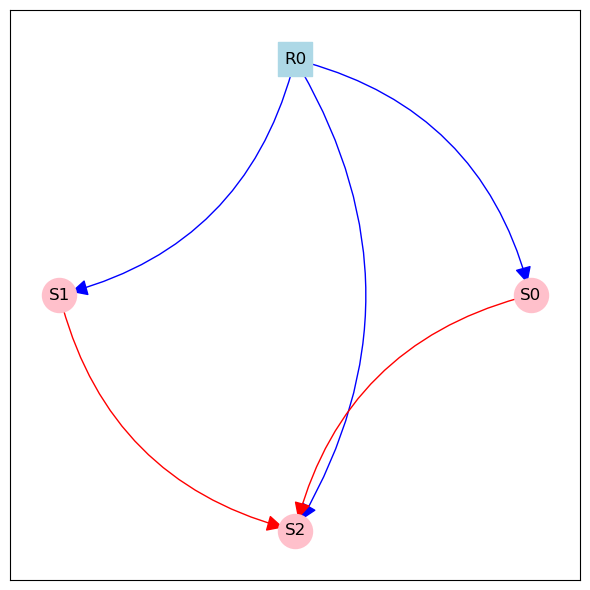

In [37]:
NR = 1
NS = 3

n_paths = 3
sample_idx = 2
adjacency_matrix = networks[n_paths][sample_idx]['adjacency_matrix_0']
input_substrates_list = networks[n_paths][sample_idx]['input_substrates_list']
visualize_dag_signaling_network(adjacency_matrix, input_substrates_list, NR, NS)
print("Done")

In [ ]:
dR_dC, dR_dC_func, dR_dl, dR_dl_func, dR_dk, dR_dk_func, remaining_syms = sim.get_first_order_derivatives()
dC_dl_til = - dR_dC.adjugate() @ dR_dl

# Get the expression for the target species
expr = dC_dl_til[NR+NS-2,0]

# Get all variables that appear in the expression
variables = [var for var in expr.free_symbols if not str(var).startswith('k_')]
print(variables)

# Create the polynomial in all variables
poly = Poly(expr, variables)

print("Polynomial:", poly)
print("Variables:", variables)
print("Degrees in each variable:")
# for var in variables:
#     print(f"{var}: {poly.degree(var)}")
print("Total degree:", poly.total_degree())
print("Number of terms:", len(poly.terms()))

target_node = 'S'+str(NR+NS-2)
G = get_digraph_from_adjacency_matrix(adjacency_matrix, input_substrates, NR, NS)
print("Number of paths:", len(count_simple_paths(G, 'R0', target_node)))



[S1s, const3, S2s, const4, const1, S0s, S3s, const0, const2]
Polynomial: Poly((k_1*k_13*k_16*k_8 + k_1*k_13*k_16*k_9 + k_1*k_13*k_17*k_8 + k_1*k_13*k_17*k_9 + k_10*k_16*k_3*k_8 + k_10*k_16*k_3*k_9 + k_10*k_17*k_3*k_8 + k_10*k_17*k_3*k_9)*S1s**2*const3*const4 + (-k_1*k_12*k_16*k_8 - k_1*k_12*k_16*k_9 - k_1*k_12*k_17*k_8 - k_1*k_12*k_17*k_9 - k_1*k_13*k_16*k_8 - k_1*k_13*k_16*k_9 - k_1*k_13*k_17*k_8 - k_1*k_13*k_17*k_9 - k_10*k_16*k_2*k_8 - k_10*k_16*k_2*k_9 - k_10*k_16*k_3*k_8 - k_10*k_16*k_3*k_9 - k_10*k_17*k_2*k_8 - k_10*k_17*k_2*k_9 - k_10*k_17*k_3*k_8 - k_10*k_17*k_3*k_9)*S1s**2*const3*S3s + (-k_0*k_13*k_16*k_8 - k_0*k_13*k_16*k_9 - k_0*k_13*k_17*k_8 - k_0*k_13*k_17*k_9 - k_1*k_13*k_16*k_8 - k_1*k_13*k_16*k_9 - k_1*k_13*k_17*k_8 - k_1*k_13*k_17*k_9)*S1s**2*S2s*const4 + (k_0*k_12*k_16*k_8 + k_0*k_12*k_16*k_9 + k_0*k_12*k_17*k_8 + k_0*k_12*k_17*k_9 + k_0*k_13*k_16*k_8 + k_0*k_13*k_16*k_9 + k_0*k_13*k_17*k_8 + k_0*k_13*k_17*k_9 + k_1*k_12*k_16*k_8 + k_1*k_12*k_16*k_9 + k_1*k_12*k_17*k_

# Sampling methods

In [18]:
from typing import List, Dict, Tuple, Iterator

def latin_hypercube_sampling(ranges: List[Tuple[float, float]], K: int, seed: int = None) -> Iterator[List[float]]:
    """
    Generate Latin Hypercube Sampling (LHS) samples.
    
    Latin Hypercube Sampling ensures good coverage of the parameter space by dividing
    each dimension into K bins and ensuring each bin is sampled exactly once.
    
    Args:
        ranges: List of (min, max) tuples defining the range for each dimension
        K: Number of bins per dimension (and total number of samples)
        seed: Random seed for reproducibility (optional)
    
    Yields:
        List[float]: A sample point with one value per dimension
        
    Example:
        >>> ranges = [(0, 1), (0, 10), (-1, 1)]
        >>> samples = latin_hypercube_sampling(ranges, K=5)
        >>> for sample in samples:
        ...     print(sample)  # [0.2, 3.4, -0.1], [0.8, 7.2, 0.6], etc.
    """
    if seed is not None:
        np.random.seed(seed)
    
    n_dims = len(ranges)
    
    # Create a K x n_dims matrix to store bin assignments
    # Each row represents one sample, each column represents one dimension
    bin_assignments = np.zeros((K, n_dims), dtype=int)
    
    # For each dimension, randomly assign each bin (0 to K-1) to exactly one sample
    for dim in range(n_dims):
        bin_assignments[:, dim] = np.random.permutation(K)
    
    # Generate samples
    for sample_idx in range(K):
        sample = []
        for dim in range(n_dims):
            min_val, max_val = ranges[dim]
            bin_idx = bin_assignments[sample_idx, dim]
            
            # Calculate bin boundaries
            bin_width = (max_val - min_val) / K
            bin_min = min_val + bin_idx * bin_width
            bin_max = bin_min + bin_width
            
            # Sample uniformly within the bin
            sample_value = np.random.uniform(bin_min, bin_max)
            sample.append(sample_value)
        
        yield sample


def test_latin_hypercube_sampling():
    """
    Test function to demonstrate Latin Hypercube Sampling.
    """
    # Example: 3-dimensional parameter space
    ranges = [(0, 1), (0, 10), (-1, 1)]
    K = 5
    
    print("Latin Hypercube Sampling Example:")
    print(f"Ranges: {ranges}")
    print(f"Number of samples (K): {K}")
    print("Samples:")
    
    samples = list(latin_hypercube_sampling(ranges, K, seed=42))
    for i, sample in enumerate(samples):
        print(f"  Sample {i+1}: {sample}")
    
    # Verify we get exactly K samples
    assert len(samples) == K, f"Expected {K} samples, got {len(samples)}"
    
    # Verify each sample has the correct number of dimensions
    for sample in samples:
        assert len(sample) == len(ranges), f"Expected {len(ranges)} dimensions, got {len(sample)}"
    
    print("Test passed!")

test_latin_hypercube_sampling()


Latin Hypercube Sampling Example:
Ranges: [(0, 1), (0, 10), (-1, 1)]
Number of samples (K): 5
Samples:
  Sample 1: [0.3732352291549871, 7.202230023486417, -0.3167709688815818]
  Sample 2: [0.8041168988591605, 3.9398197043239884, -0.6670229436798313]
  Sample 3: [0.4424678221356553, 4.363649934414202, 0.2733618039413737]
  Sample 4: [0.06084844859190755, 1.0495128632644757, 0.7727780074568463]
  Sample 5: [0.6582458280396084, 9.22370578944476, -0.14420245573918322]
Test passed!


In [73]:

import time

num_samples = 50
NR = 1
NS = 4
p_f = 0.75
p_r = 0.5

degree_list = []
term_list = []
degree_const_list = []
term_const_list = []
degree_S_list = []
term_S_list = []
paths_list = []
target_node = 'S'+str(NR+NS-2)

timing_stats = {
    'network_generation': 0,
    'simulator_setup': 0, 
    'derivatives': 0,
    'polynomial_analysis': 0,
    'path_counting': 0
}

for n in range(num_samples):
    try:
        t0 = time.time()
        species_names, reaction_strings, L, adjacency_matrix, input_substrates = generate_dag_signaling_network(NR, NS, p_f, p_r, include_reverse=False, include_uncatalyzed=True)

        r_n = ReactionNetwork.from_reaction_strings(
            reaction_strings=reaction_strings,
            L=L,
            seed=42,
            species_names=species_names,
            force_reverse=True
        )
        timing_stats['network_generation'] += time.time() - t0

        t0 = time.time()
        sim = ReactionNetworkSimulator(r_n)
        sim.solve_conservation_laws()
        timing_stats['simulator_setup'] += time.time() - t0

        t0 = time.time()
        dR_dC, dR_dC_func, dR_dl, dR_dl_func, dR_dk, dR_dk_func, remaining_syms = sim.get_first_order_derivatives()
        dC_dl_til = - dR_dC.adjugate() @ dR_dl
        timing_stats['derivatives'] += time.time() - t0

        expr = dC_dl_til[NR+NS-2,0]

        t0 = time.time()
        # Get all variables that appear in the expression
        variables = [var for var in expr.free_symbols if not str(var).startswith('k_')]
        const_variables = [var for var in expr.free_symbols if str(var).startswith('const')]
        S_variables = [var for var in expr.free_symbols if str(var).startswith('S')]

        # Create the polynomial in all variables
        poly = Poly(expr, variables)
        degree_list.append(poly.total_degree())
        term_list.append(len(poly.terms()))

        # poly = Poly(expr, const_variables)
        # degree_const_list.append(poly.total_degree())
        # term_const_list.append(len(poly.terms()))

        # poly = Poly(expr, S_variables)
        # degree_S_list.append(poly.total_degree())
        # term_S_list.append(len(poly.terms()))
        # timing_stats['polynomial_analysis'] += time.time() - t0

        t0 = time.time()
        G = get_digraph_from_adjacency_matrix(adjacency_matrix, input_substrates, NR, NS)
        paths_list.append(len(count_simple_paths(G, 'R0', target_node)))
        timing_stats['path_counting'] += time.time() - t0

        if n%10 == 0:
            print(f"Completed {n} samples")
            print("Timing stats so far:")
            for k,v in timing_stats.items():
                print(f"{k}: {v:.2f}s")
            print()
            
    except Exception as e:
        print(f"Error in iteration {n}: {str(e)}")
        continue

# print("\nFinal timing statistics:")
# for k,v in timing_stats.items():
#     print(f"{k}: {v:.2f}s")
#     poly = Poly(expr, const_variables)
#     degree_const_list.append(poly.total_degree())
#     term_const_list.append(len(poly.terms()))

#     poly = Poly(expr, S_variables)
#     degree_S_list.append(poly.total_degree())
#     term_S_list.append(len(poly.terms()))
#     timing_stats['polynomial_analysis'] += time.time() - t0

#     t0 = time.time()
#     G = get_digraph_from_adjacency_matrix(adjacency_matrix, input_substrates, NR, NS)
#     paths_list.append(len(count_simple_paths(G, 'R0', target_node)))
#     timing_stats['path_counting'] += time.time() - t0

#     if n%10 == 0:
#         print(f"Completed {n} samples")
#         print("Timing stats so far:")
#         for k,v in timing_stats.items():
#             print(f"{k}: {v:.2f}s")
#         print()

print("\nFinal timing statistics:")
for k,v in timing_stats.items():
    print(f"{k}: {v:.2f}s")


Completed 0 samples
Timing stats so far:
network_generation: 0.01s
simulator_setup: 0.02s
derivatives: 1.19s
polynomial_analysis: 0.00s
path_counting: 0.00s

Completed 10 samples
Timing stats so far:
network_generation: 0.02s
simulator_setup: 0.14s
derivatives: 16.98s
polynomial_analysis: 0.00s
path_counting: 0.00s

Completed 20 samples
Timing stats so far:
network_generation: 0.05s
simulator_setup: 0.28s
derivatives: 32.00s
polynomial_analysis: 0.00s
path_counting: 0.00s

Completed 30 samples
Timing stats so far:
network_generation: 0.07s
simulator_setup: 0.40s
derivatives: 45.30s
polynomial_analysis: 0.00s
path_counting: 0.00s

Completed 40 samples
Timing stats so far:
network_generation: 0.09s
simulator_setup: 0.53s
derivatives: 64.94s
polynomial_analysis: 0.00s
path_counting: 0.00s


Final timing statistics:
network_generation: 0.11s
simulator_setup: 0.64s
derivatives: 77.13s
polynomial_analysis: 0.00s
path_counting: 0.00s


In [68]:
from CRNs import *
import numpy as np
import matplotlib.pyplot as plt
import sympy
import networkx as nx
import random

# NR = 1
# NS = 2
# p_f = 0.75
# p_r = 0.5
# species_names, reaction_strings, L, adjacency_matrix, input_substrates = generate_dag_signaling_network(NR, NS, p_f, p_r, include_reverse=True, include_uncatalyzed=True)

adjacency_matrix = np.array([[0, 1], [1, 0]])
input_substrates_list = [[0,1]]
species_names, reaction_strings, L = generate_specified_dag_signaling_network(adjacency_matrix, input_substrates_list, include_reverse=True, include_uncatalyzed=True)

print(adjacency_matrix)
print(reaction_strings)
r_n = ReactionNetwork.from_reaction_strings(
    reaction_strings=reaction_strings,
    L=L,
    seed=42,
    species_names=species_names,
    force_reverse=True
)

t0 = time.time()
sim = ReactionNetworkSimulator(r_n)
sim.solve_conservation_laws()


t0 = time.time()
dR_dC, dR_dC_func, dR_dl, dR_dl_func, dR_dk, dR_dk_func, remaining_syms = sim.get_first_order_derivatives()
dC_dl_til = - dR_dC.adjugate() @ dR_dl

[[0 1]
 [1 0]]
['R0+S0s -> R0+S0', 'R0+S0 -> R0+S0s', 'R0+S1s -> R0+S1', 'R0+S1 -> R0+S1s', 'S0+S1s -> S0+S1', 'S0+S1 -> S0+S1s', 'S1+S0s -> S1+S0', 'S1+S0 -> S1+S0s', 'S0s -> S0', 'S0 -> S0s', 'S1s -> S1', 'S1 -> S1s']


In [69]:
from sympy import Poly, Symbol

expr = dC_dl_til[0,0]

variables = [var for var in expr.free_symbols if not str(var).startswith('k_')]
const_variables = [var for var in expr.free_symbols if str(var).startswith('const')]
S_variables = [var for var in expr.free_symbols if str(var).startswith('S')]

# Create the polynomial in all variables
poly = Poly(expr, const_variables)
print(poly)

Poly((-k_13*k_5 - k_13*k_6 - k_14*k_5 - k_14*k_6)*const2*const1 + (S0s*k_12*k_5 + S0s*k_12*k_6 + S0s*k_13*k_5 + S0s*k_13*k_6 + S0s*k_14*k_5 + S0s*k_14*k_6 + S0s*k_15*k_5 + S0s*k_15*k_6)*const2 + (k_1*k_10 + k_1*k_11 + k_1*k_8 + k_1*k_9 + k_10*k_2 + k_11*k_2 + k_2*k_8 + k_2*k_9)*const1**2 + (k_1*k_4 + k_1*k_5 + k_1*k_6 + k_1*k_7 + k_2*k_4 + k_2*k_5 + k_2*k_6 + k_2*k_7)*const1*const0 + (-S0s*k_0*k_10 - S0s*k_0*k_11 - S0s*k_0*k_8 - S0s*k_0*k_9 - 2*S0s*k_1*k_10 - 2*S0s*k_1*k_11 - 2*S0s*k_1*k_8 - 2*S0s*k_1*k_9 - 2*S0s*k_10*k_2 - S0s*k_10*k_3 - 2*S0s*k_11*k_2 - S0s*k_11*k_3 - 2*S0s*k_2*k_8 - 2*S0s*k_2*k_9 - S0s*k_3*k_8 - S0s*k_3*k_9 + S1s*k_13*k_4 + S1s*k_13*k_5 + S1s*k_13*k_6 + S1s*k_13*k_7 + S1s*k_14*k_4 + S1s*k_14*k_5 + S1s*k_14*k_6 + S1s*k_14*k_7 + k_1*k_20 + k_1*k_21 + k_1*k_22 + k_1*k_23 + k_2*k_20 + k_2*k_21 + k_2*k_22 + k_2*k_23)*const1 + (-S0s*k_0*k_4 - S0s*k_0*k_5 - S0s*k_0*k_6 - S0s*k_0*k_7 - S0s*k_1*k_4 - S0s*k_1*k_5 - S0s*k_1*k_6 - S0s*k_1*k_7 - S0s*k_2*k_4 - S0s*k_2*k_5 - S0s*k

In [82]:
E_range = 5.0
B_range = 5.0
F_range = 5.0
C0 = 1
beta = 1
l0_range = (1e-3, 1e3)
n_cons = len(L)
reac_rates = generate_thermodynamic_rates(r_n, C0, beta, E_range, B_range, F_range)
default_l0 = np.exp(np.random.uniform(np.log(l0_range[0]), np.log(l0_range[1]), n_cons))

# Create substitution dictionary for rate constants
rate_subs = {Symbol(f'k_{i}'): reac_rates[i] for i in range(len(reac_rates))}

# Create substitution dictionary for conservation constants  
const_subs = {Symbol(f'const{i+1}'): default_l0[i+1] for i in range(len(default_l0)-1)}

# Combine substitutions and evaluate expression
expr_eval = expr.subs({**rate_subs, **const_subs})
expr_eval

(0.000148748831149436 - 107.180169357623*S1s)*(0.510076377709039*S0s - 0.227283443925603) + (0.0912426857140559 - 0.280946298503548*S0s)*(-171.687064079671*S0s + 107.180169357623*const0 + 1727.72313036261)

Expression: (0.000148748831149436 - 107.180169357623*S1s)*(0.510076377709039*S0s - 0.227283443925603) + (0.0912426857140559 - 0.280946298503548*S0s)*(-171.687064079671*S0s + 107.180169357623*const0 + 1727.72313036261)
Simplified: -(0.280946298503548*S0s - 0.0912426857140559)*(-171.687064079671*S0s + 107.180169357623*const0 + 1727.72313036261) - (0.510076377709039*S0s - 0.227283443925603)*(107.180169357623*S1s - 0.000148748831149436)
Computing positive roots for each (S0s, const0) pair...


C:\Users\csfloyd\AppData\Local\Temp\ipykernel_74376\1915441131.py:38: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  root = fsolve(f, initial_guess)[0]


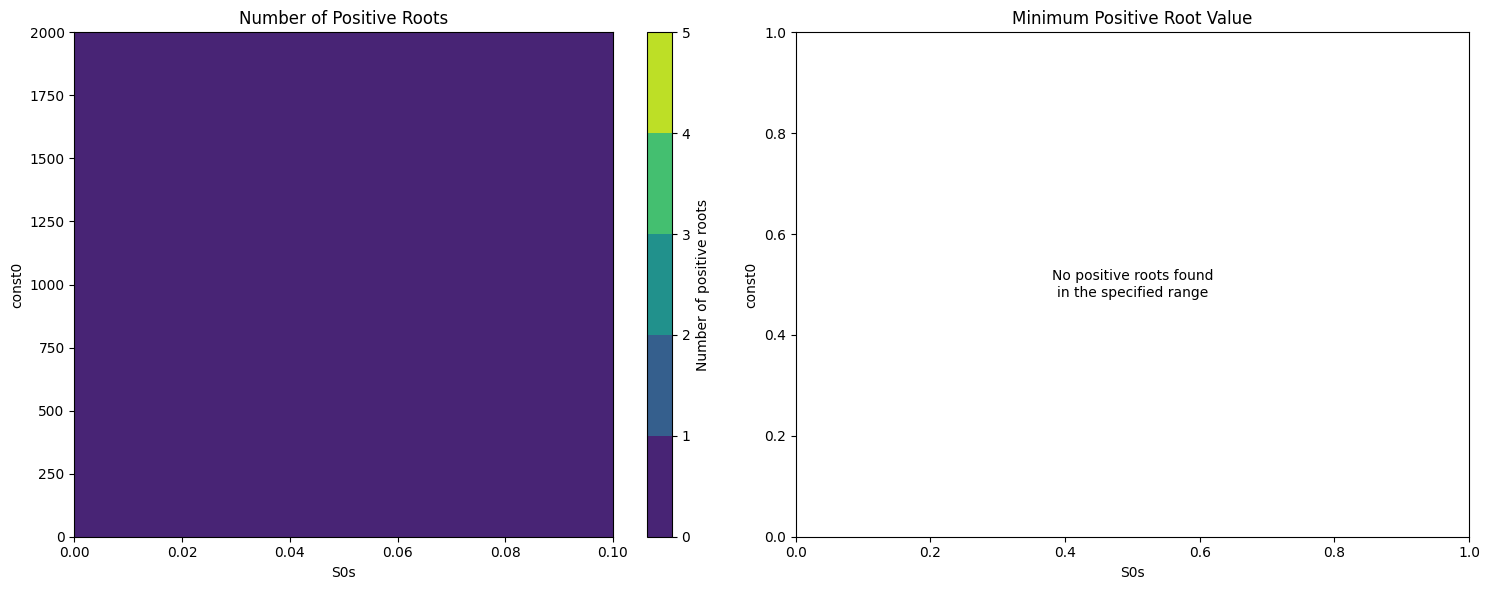


Statistics:
Total grid points: 100000
Points with positive roots: 0
Maximum number of roots at any point: 0


In [86]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from sympy import symbols, lambdify
from scipy.optimize import fsolve

# Define the expression
S0s, S1s, const0 = symbols('S0s S1s const0')


print("Expression:", expr_eval)
print("Simplified:", sp.simplify(expr_eval))

# Create a function to evaluate the expression
expr_func = lambdify([S0s, S1s, const0], expr_eval, 'numpy')

# Define parameter ranges
S0s_range = np.linspace(0, 0.1, 100)  # Adjust range as needed
const0_range = np.linspace(0, 2000, 1000)  # Adjust range as needed

# Create meshgrid
S0s_grid, const0_grid = np.meshgrid(S0s_range, const0_range)

# For each (S0s, const0) pair, find S1s that makes the expression = 0
# We'll solve: expr(S0s, S1s, const0) = 0 for S1s
def find_positive_roots(S0s_val, const0_val):
    """Find positive roots of S1s for given S0s and const0"""
    try:
        # Create a function f(S1s) = expr(S0s_val, S1s, const0_val)
        def f(S1s_val):
            return expr_func(S0s_val, S1s_val, const0_val)
        
        # Try to find roots using fsolve
        # We'll try different initial guesses
        roots = []
        for initial_guess in [0.001, 0.01, 0.1, 1.0]:
            try:
                root = fsolve(f, initial_guess)[0]
                if root > 0 and abs(f(root)) < 1e-6:  # Check if it's a valid positive root
                    roots.append(root)
            except:
                continue
        
        # Remove duplicates and return
        unique_roots = []
        for root in roots:
            if not any(abs(root - existing) < 1e-6 for existing in unique_roots):
                unique_roots.append(root)
        
        return unique_roots
    except:
        return []

# Create a grid to store the number of positive roots
root_count_grid = np.zeros_like(S0s_grid)
min_positive_root_grid = np.full_like(S0s_grid, np.nan)

print("Computing positive roots for each (S0s, const0) pair...")
for i in range(len(const0_range)):
    for j in range(len(S0s_range)):
        S0s_val = S0s_range[j]
        const0_val = const0_range[i]
        
        positive_roots = find_positive_roots(S0s_val, const0_val)
        root_count_grid[i, j] = len(positive_roots)
        
        if positive_roots:
            min_positive_root_grid[i, j] = min(positive_roots)

# Create the contour plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Number of positive roots
contour1 = ax1.contourf(S0s_grid, const0_grid, root_count_grid, levels=range(6), cmap='viridis')
ax1.set_xlabel('S0s')
ax1.set_ylabel('const0')
ax1.set_title('Number of Positive Roots')
plt.colorbar(contour1, ax=ax1, label='Number of positive roots')

# Plot 2: Minimum positive root value (where roots exist)
mask = ~np.isnan(min_positive_root_grid)
if np.any(mask):
    contour2 = ax2.contourf(S0s_grid, const0_grid, min_positive_root_grid, levels=20, cmap='plasma')
    ax2.set_xlabel('S0s')
    ax2.set_ylabel('const0')
    ax2.set_title('Minimum Positive Root Value')
    plt.colorbar(contour2, ax=ax2, label='Minimum positive root')
else:
    ax2.text(0.5, 0.5, 'No positive roots found\nin the specified range', 
             ha='center', va='center', transform=ax2.transAxes)
    ax2.set_xlabel('S0s')
    ax2.set_ylabel('const0')
    ax2.set_title('Minimum Positive Root Value')

plt.tight_layout()
plt.show()

# Print some statistics
print(f"\nStatistics:")
print(f"Total grid points: {S0s_grid.size}")
print(f"Points with positive roots: {np.sum(root_count_grid > 0)}")
print(f"Maximum number of roots at any point: {int(np.max(root_count_grid))}")
if np.any(mask):
    print(f"Range of minimum positive roots: {np.nanmin(min_positive_root_grid):.6f} to {np.nanmax(min_positive_root_grid):.6f}")